<a href="https://colab.research.google.com/github/mrayhanz/244107020027-Machine-Learning/blob/main/TG4_244107020027_Muhammad_Rayhan_Zamzami.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IDENTITAS DIRI
Nama : Muhammad Rayhan Zamzami

NIM : 244107020027

Kelas : TI-3G

Absen : 19

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('/content/drive/MyDrive/ml-semester5/dataset/Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


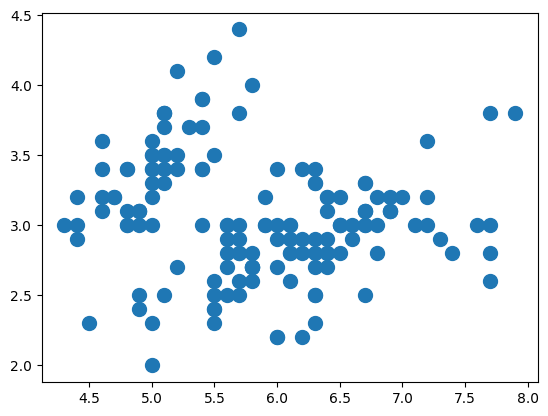

In [7]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [8]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

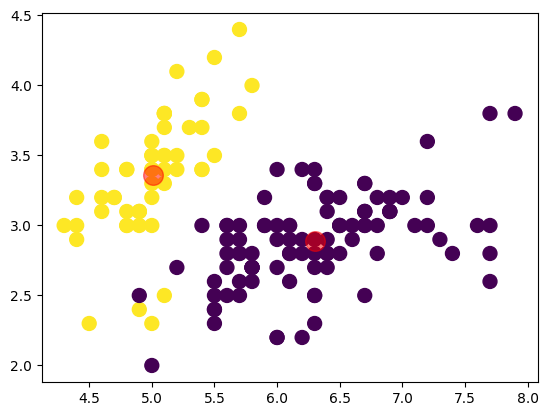

In [9]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [10]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


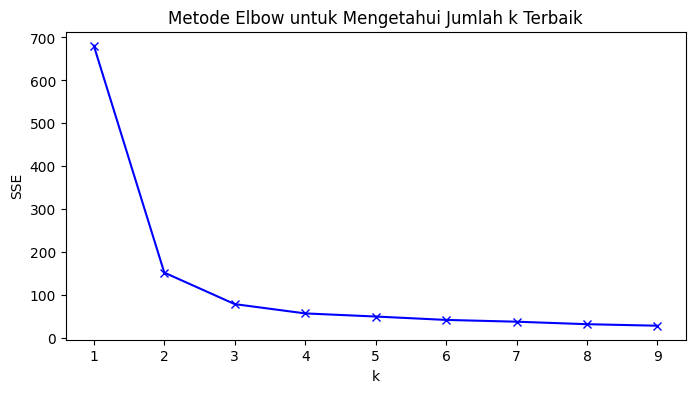

In [12]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [13]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.317873214285726
k=5; SSE=50.06117265087851
k=6; SSE=42.163217391304364
k=7; SSE=38.00850155195682
k=8; SSE=32.19943722943724
k=9; SSE=28.643904957763667


# PRAKTIKUM 2

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

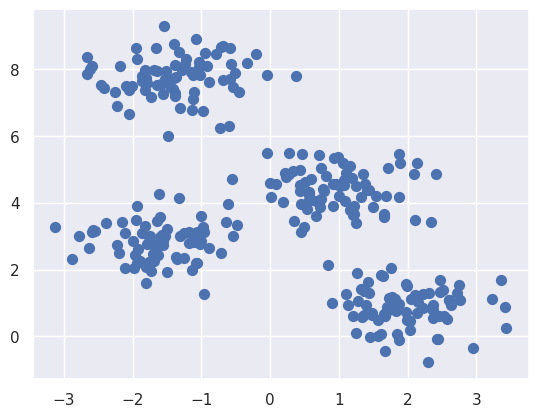

In [15]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [16]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

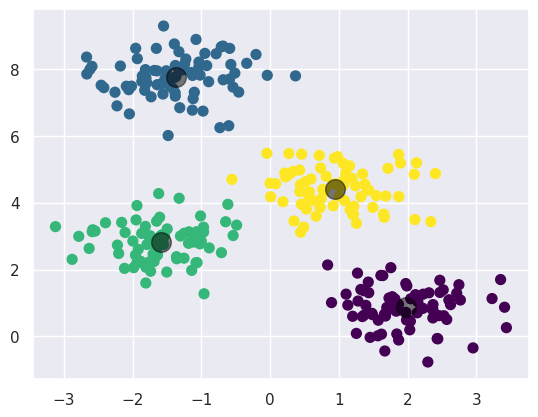

In [17]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

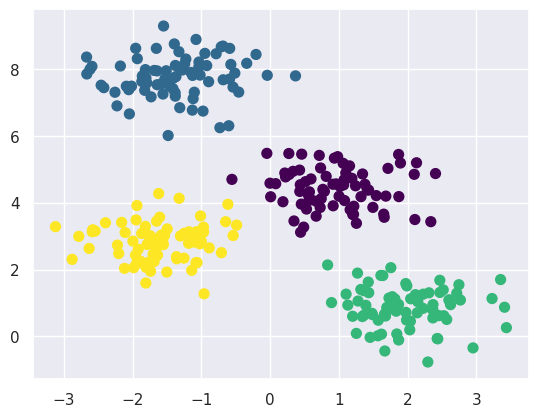

In [18]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

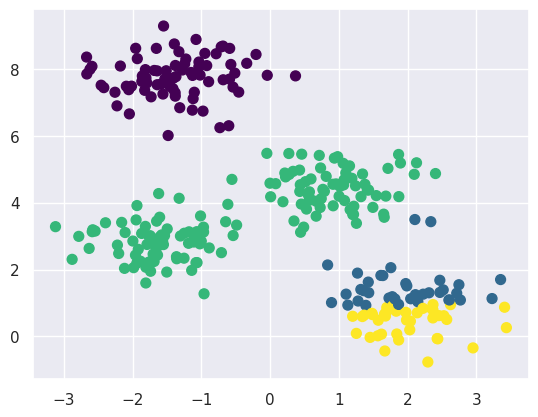

In [19]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

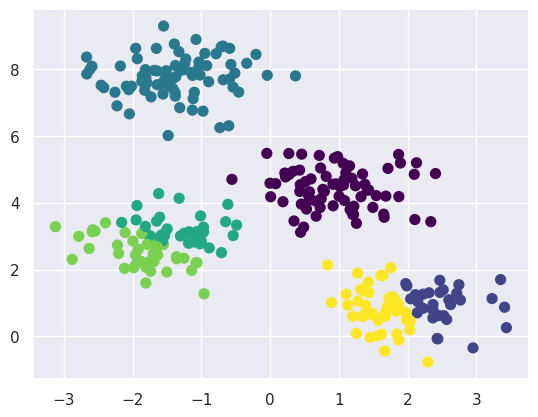

In [22]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [24]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

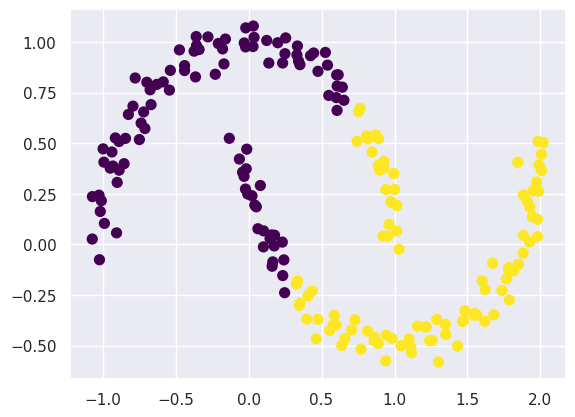

In [25]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

In [26]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [27]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

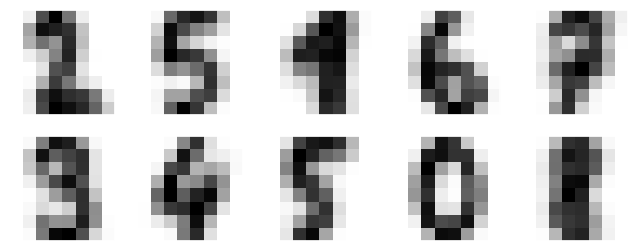

In [28]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [29]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [30]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

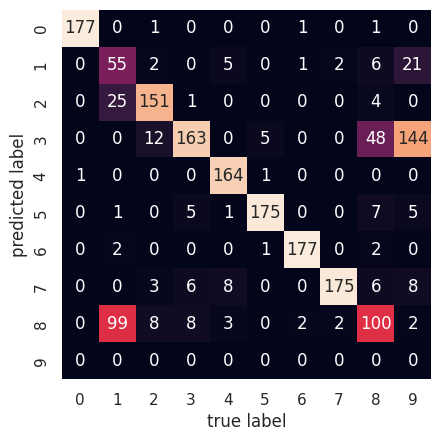

In [31]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [32]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

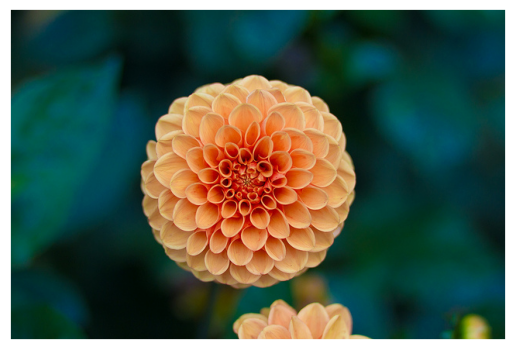

In [33]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [34]:
flower.shape

(427, 640, 3)

In [35]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [36]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

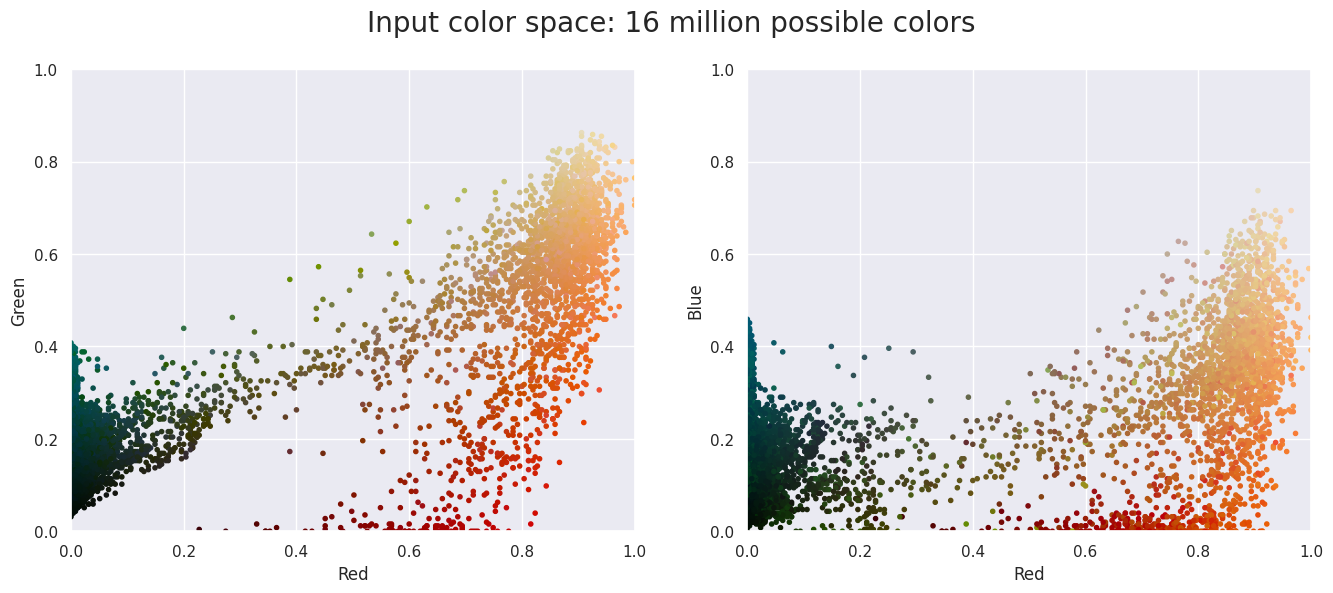

In [37]:
plot_pixels(data, title='Input color space: 16 million possible colors')

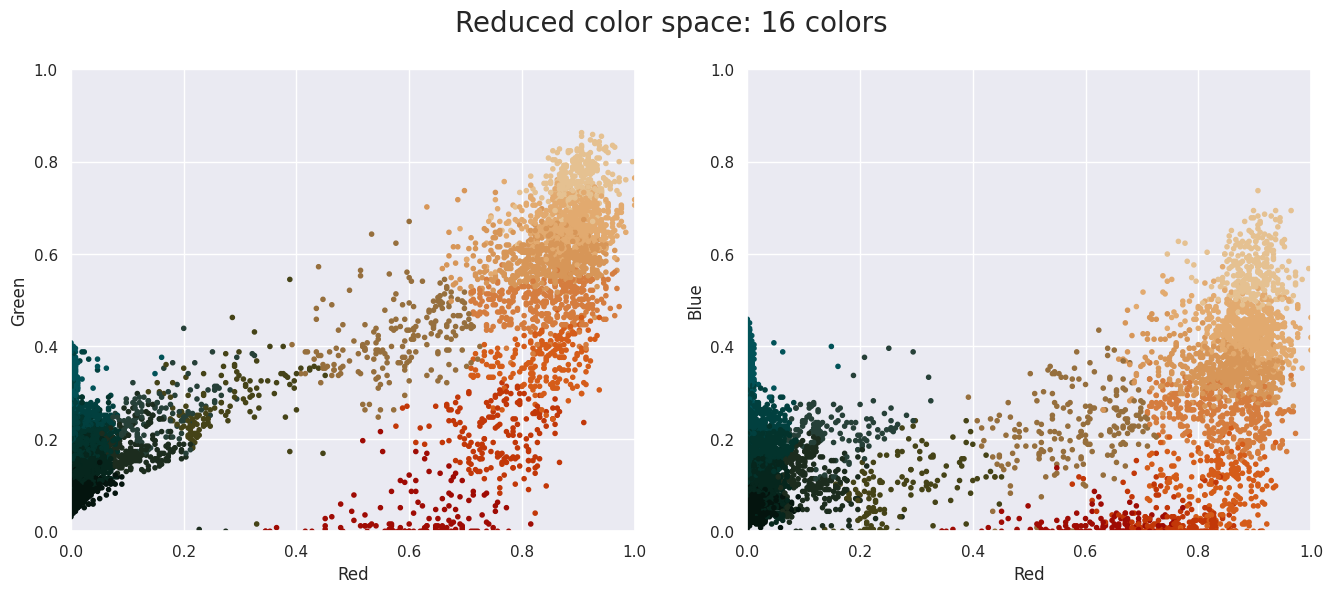

In [38]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

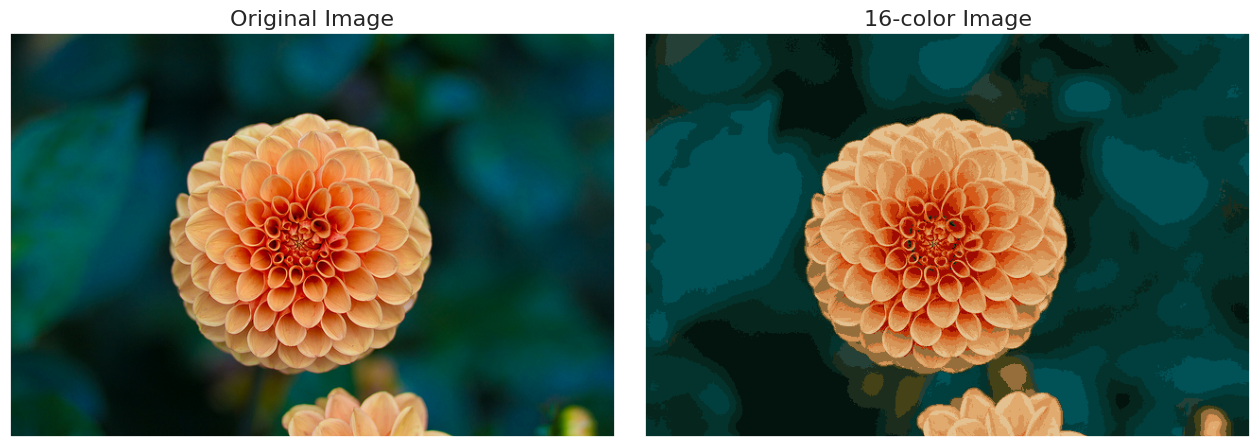

In [39]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# PRAKTIKUM 3

In [41]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

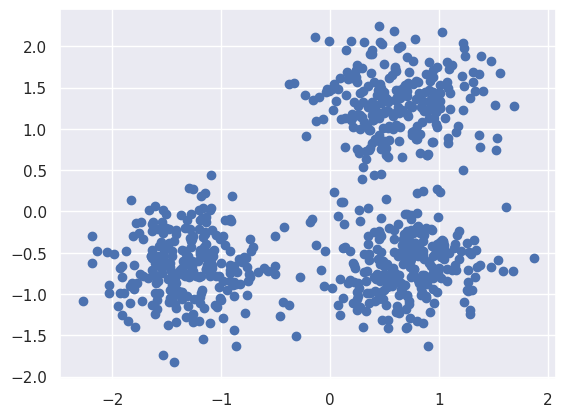

In [43]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [46]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


In [48]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


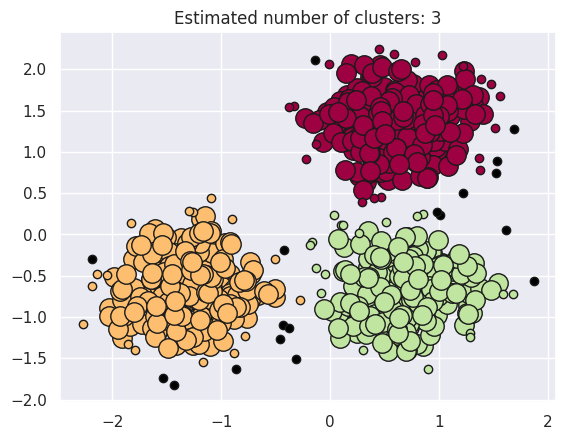

In [50]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# TUGAS PRAKTIKUM

## Tugas 1

In [51]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [52]:
df = pd.read_csv('/content/drive/MyDrive/ml-semester5/dataset/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [59]:
# Menentukan fitur yang digunakan untuk clustering
fitur = ['Annual Income (k$)', 'Spending Score (1-100)']

data = df.loc[:, fitur]

# Standardisasi data
scaler = StandardScaler()
X = scaler.fit_transform(data)

In [60]:
# Mencari jumlah cluster menggunakan metode Elbow
nilai_k = range(2, 11)
sse = []

for jumlah in nilai_k:
    model = KMeans(
        n_clusters=jumlah,
        random_state=0,
        n_init=10
    )

    model.fit(X)
    sse.append(model.inertia_)

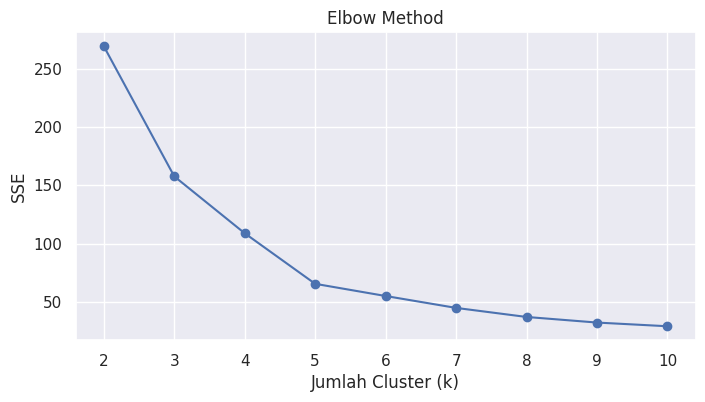

In [61]:
# Visualisasi Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(nilai_k, sse, marker='o')

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SSE')
plt.title('Elbow Method')

plt.show()

In [62]:
for jumlah, nilai in zip(nilai_k, sse):
    print(f'Jumlah cluster = {jumlah}, SSE = {nilai:.4f}')

Jumlah cluster = 2, SSE = 269.2993
Jumlah cluster = 3, SSE = 157.7040
Jumlah cluster = 4, SSE = 108.9213
Jumlah cluster = 5, SSE = 65.5684
Jumlah cluster = 6, SSE = 55.1142
Jumlah cluster = 7, SSE = 44.9112
Jumlah cluster = 8, SSE = 37.1481
Jumlah cluster = 9, SSE = 32.3458
Jumlah cluster = 10, SSE = 29.1790


In [63]:
# Membuat model akhir dengan k = 5
k_terbaik = 5

model_kmeans = KMeans(
    n_clusters=k_terbaik,
    random_state=0,
    n_init=10
)

cluster = model_kmeans.fit_predict(X)

df['Cluster'] = cluster

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


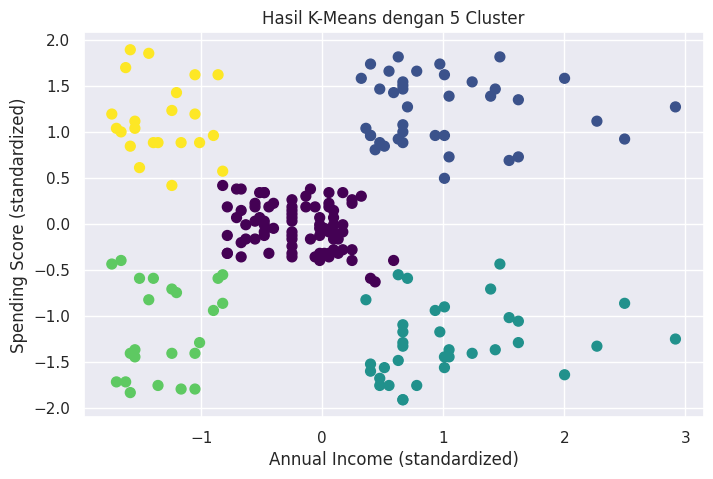

In [64]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=cluster,
    s=50,
    cmap='viridis'
)

plt.xlabel('Annual Income (standardized)')
plt.ylabel('Spending Score (standardized)')
plt.title(f'Hasil K-Means dengan {k_terbaik} Cluster')

plt.show()

## Tugas 2

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

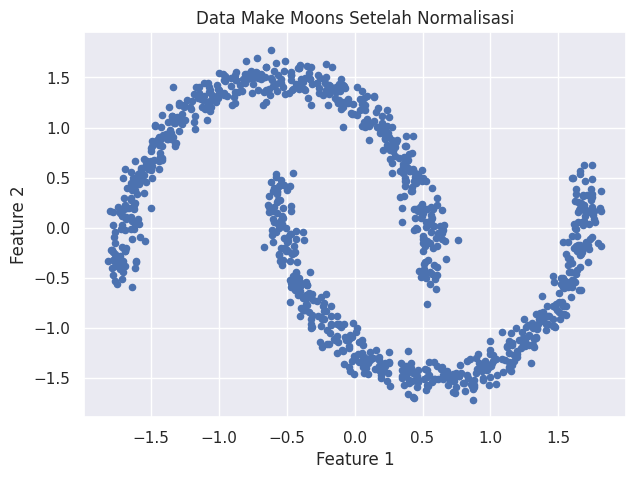

In [66]:
X, y_true = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=0
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=20)
plt.title('Data Make Moons Setelah Normalisasi')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [67]:
dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

hasil_cluster = dbscan.fit_predict(X_scaled)

In [68]:
cluster_ids = set(hasil_cluster)

jumlah_cluster = len(cluster_ids - {-1})
jumlah_noise = np.sum(hasil_cluster == -1)

print("Jumlah cluster :", jumlah_cluster)
print("Jumlah noise   :", jumlah_noise)

Jumlah cluster : 2
Jumlah noise   : 0


In [69]:
homogeneity = metrics.homogeneity_score(y_true, hasil_cluster)
completeness = metrics.completeness_score(y_true, hasil_cluster)
v_measure = metrics.v_measure_score(y_true, hasil_cluster)
ari = metrics.adjusted_rand_score(y_true, hasil_cluster)
ami = metrics.adjusted_mutual_info_score(y_true, hasil_cluster)

if jumlah_cluster >= 2:
    silhouette = metrics.silhouette_score(X_scaled, hasil_cluster)
else:
    silhouette = np.nan

print(f"Homogeneity : {homogeneity:.3f}")
print(f"Completeness: {completeness:.3f}")
print(f"V-measure   : {v_measure:.3f}")
print(f"ARI         : {ari:.3f}")
print(f"AMI         : {ami:.3f}")
print(f"Silhouette  : {silhouette:.3f}")

Homogeneity : 1.000
Completeness: 1.000
V-measure   : 1.000
ARI         : 1.000
AMI         : 1.000
Silhouette  : 0.392


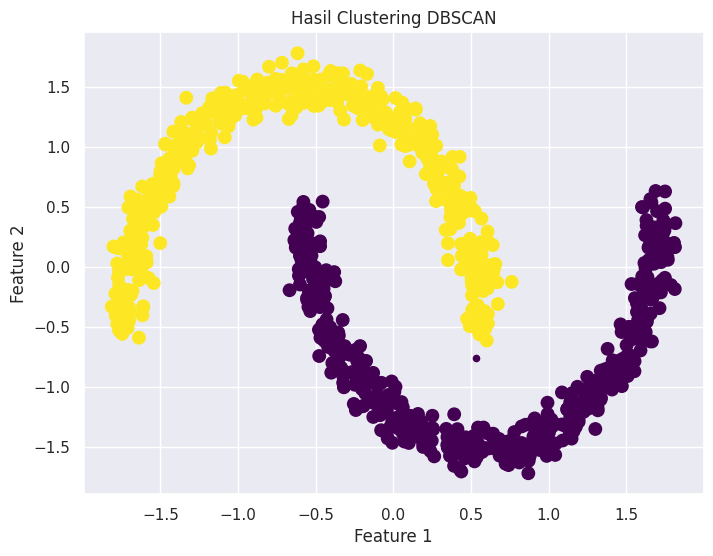

In [70]:
core_mask = np.zeros(hasil_cluster.shape, dtype=bool)
core_mask[dbscan.core_sample_indices_] = True

noise_mask = hasil_cluster == -1
noncore_mask = (~core_mask) & (~noise_mask)

plt.figure(figsize=(8, 6))

# Non-core
plt.scatter(
    X_scaled[noncore_mask, 0],
    X_scaled[noncore_mask, 1],
    s=20,
    c=hasil_cluster[noncore_mask],
    cmap='viridis'
)

# Core
plt.scatter(
    X_scaled[core_mask, 0],
    X_scaled[core_mask, 1],
    s=80,
    c=hasil_cluster[core_mask],
    cmap='viridis'
)

# Noise
plt.scatter(
    X_scaled[noise_mask, 0],
    X_scaled[noise_mask, 1],
    s=25,
    c='black'
)

plt.title('Hasil Clustering DBSCAN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [71]:
daftar_eps = [0.05, 0.1, 0.3, 0.5]
daftar_min_samples = [3, 10, 20]

hasil_pengujian = []

for nilai_eps in daftar_eps:
    for nilai_min in daftar_min_samples:

        model = DBSCAN(
            eps=nilai_eps,
            min_samples=nilai_min
        )

        prediksi = model.fit_predict(X_scaled)

        cluster_terbentuk = len(set(prediksi) - {-1})
        noise_terdeteksi = np.sum(prediksi == -1)

        hom = metrics.homogeneity_score(y_true, prediksi)
        comp = metrics.completeness_score(y_true, prediksi)
        v = metrics.v_measure_score(y_true, prediksi)
        ari_value = metrics.adjusted_rand_score(y_true, prediksi)
        ami_value = metrics.adjusted_mutual_info_score(y_true, prediksi)

        if cluster_terbentuk >= 2:
            sil = metrics.silhouette_score(X_scaled, prediksi)
        else:
            sil = np.nan

        hasil_pengujian.append({
            'eps': nilai_eps,
            'min_samples': nilai_min,
            'clusters': cluster_terbentuk,
            'noise': noise_terdeteksi,
            'homogeneity': hom,
            'completeness': comp,
            'v_measure': v,
            'ARI': ari_value,
            'AMI': ami_value,
            'silhouette': sil
        })

In [73]:
tabel_hasil.round(3)

,eps,min_samples,clusters,noise,homogeneity,completeness,v_measure,ARI,AMI,silhouette
0,0.05,3,67,197,0.804,0.155,0.260,0.033,0.246,0.078
1,0.05,10,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
2,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
3,0.10,3,3,18,0.983,0.708,0.824,0.854,0.823,0.138
4,0.10,10,9,63,0.939,0.358,0.519,0.435,0.517,0.184
5,0.10,20,6,844,0.157,0.153,0.155,0.010,0.152,-0.409
6,0.30,3,2,0,1.000,1.000,1.000,1.000,1.000,0.392
7,0.30,10,2,0,1.000,1.000,1.000,1.000,1.000,0.392
8,0.30,20,2,0,1.000,1.000,1.000,1.000,1.000,0.392
9,0.50,3,1,0,0.000,1.000,0.000,0.000,0.000,NaN
